  - [Introduction](#header-0-introduction)
    - [Problem Statement](#header-0-problem-statement)
    - [Data Summary](#header-0-data-summary)
    - [Dependencies](#header-0-dependencies)
  - [Data Loading & Preview](#header-2-data-loading-&-preview)
  - [Exploratory Data Analysis](#header-7-exploratory-data-analysis)
    - [Univariate Analysis](#header-7-univariate-analysis)
  - [Bivariate Analysis](#header-9-bivariate-analysis)
    - [Comparing Median Value to all other features](#header-9-comparing-median-value-to-all-other-features)
    - [Visualizing Correlations: Heatmap](#header-11-visualizing-correlations--heatmap)
    - [Visualizing Correlations: Pairplot](#header-13-visualizing-correlations--pairplot)
  - [Linear Regression Model Development](#header-16-linear-regression-model-development)
    - [Split the dataset](#header-16-split-the-dataset)
    - [Create Model & Fit the Data](#header-19-create-model-&-fit-the-data)
      - [Preview R2 on Training Data](#header-21-preview-r2-on-training-data)
      - [A Manual R2 Calcuator](#header-23-a-manual-r2-calcuator)
      - [Preview R2 on Testing Data](#header-25-preview-r2-on-testing-data)
      - [RMSE on Training Data](#header-27-rmse-on-training-data)
      - [RMSE on Testing Data](#header-29-rmse-on-testing-data)
      - [Model & Feature Coefficients](#header-31-model-&-feature-coefficients)
      - [Visualize a Math Equation on Model Fit](#header-33-visualize-a-math-equation-on-model-fit)
  - [Setup For Predictions](#header-35-setup-for-predictions)# Predicting Boston Housing Prices
<a id="header-0-introduction"><h2>Introduction</h2></a><a id="header-0-problem-statement"><h3>Problem Statement</h3></a>
The problem at hand is to predict the housing prices of boston based on the data (features) provided.

<a id="header-0-data-summary"><h3>Data Summary</h3></a>
- `CRIM`: per capita crime rate by town
- `ZN`: proportion of residential land zoned for lots over 25,000 sq. ft.
- `INDUS`: proportion of non-retail business acres per town
- `CHAS`: Charles River dummy variable (= 1 if next to river; 0 otherwise)
- `NOX`: nitric oxides concentration (parts per 10 million)
- `RM`: average number of rooms per dwelling
- `AGE`: proportion of owner-occupied units built prior to 1940
- `DIS`: weighted distances to five Boston employment centers
- `RAD`: index of accessibility to radial highways
- `TAX`: full-value property-tax rate per 10,000 dollars
- `PTRATIO`: pupil-teacher ratio by town
- `LSTAT`: %lower status of the population
- `MEDV`: Median value of owner-occupied homes in 1000 dollars.

<a id="header-0-dependencies"><h3>Dependencies</h3></a>

In [15]:
%load_ext nb_black

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

The nb_black extension is already loaded. To reload it, use:
  %reload_ext nb_black


<IPython.core.display.Javascript object>

<a id="header-2-data-loading-&-preview"><h2>Data Loading & Preview</h2></a>

In [4]:
df = pd.read_csv("boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


<IPython.core.display.Javascript object>

In [6]:
rowCount, colCount = df.shape
print(f'{rowCount} rows')
print(f'{colCount} columns')

506 rows
13 columns


<IPython.core.display.Javascript object>

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


<IPython.core.display.Javascript object>

In [8]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


<IPython.core.display.Javascript object>

<a id="header-7-exploratory-data-analysis"><h2>Exploratory Data Analysis</h2></a><a id="header-7-univariate-analysis"><h3>Univariate Analysis</h3></a>Visualizing the distribution of counts of each variable

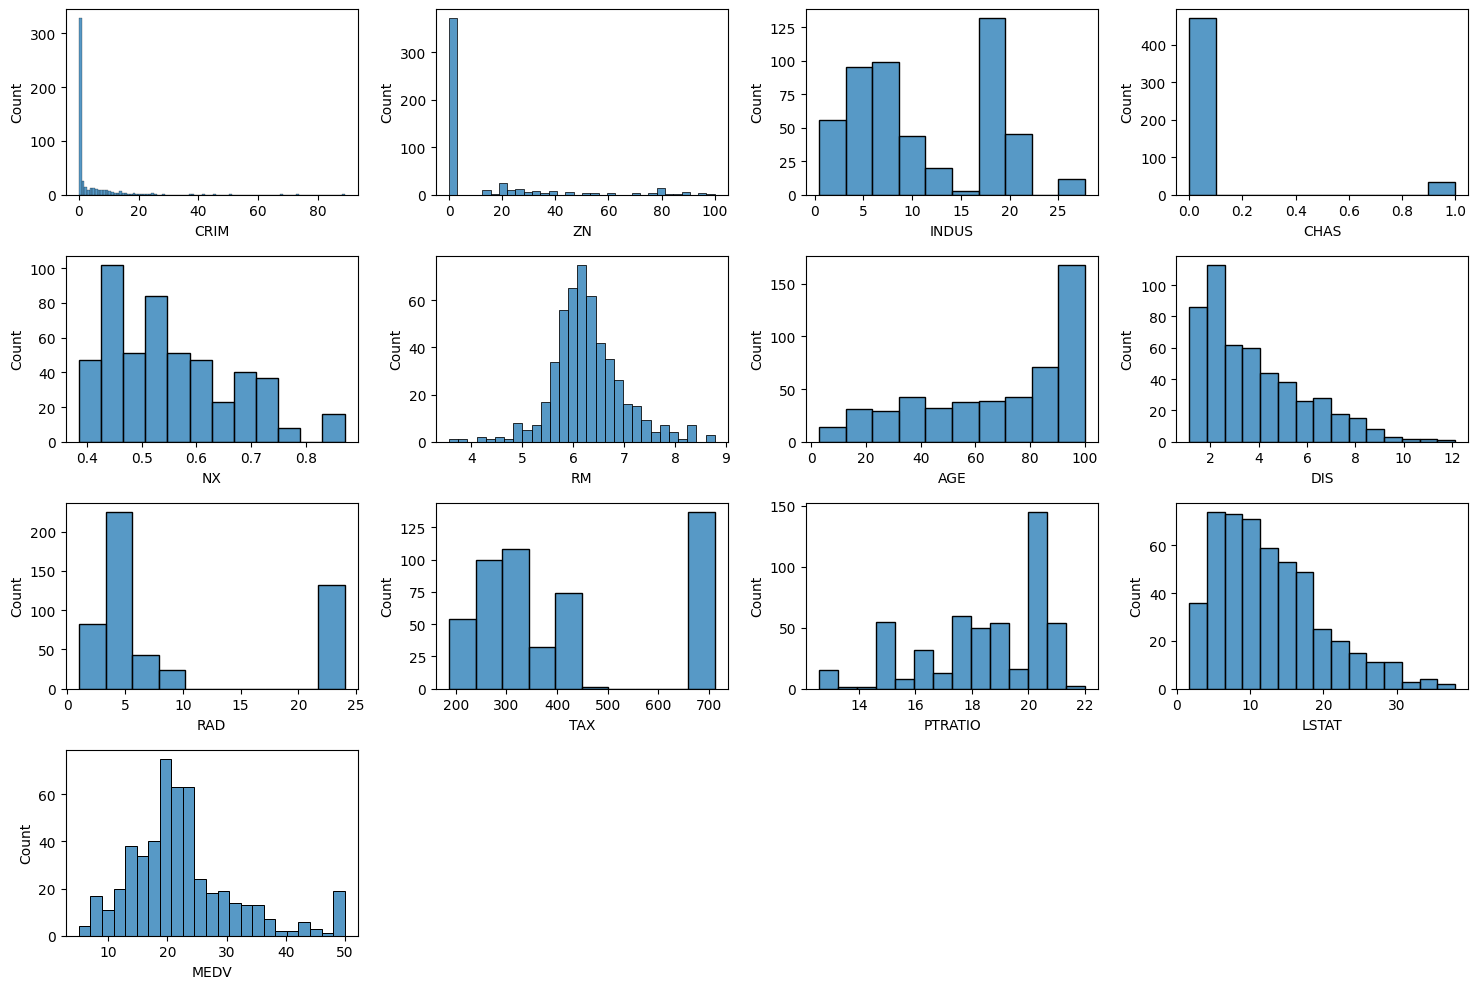

<IPython.core.display.Javascript object>

In [16]:
# defining the figure size
plt.figure(figsize=(15, 10))

features = df.columns

for i, feature in enumerate(features):
    plt.subplot(4, 4, i+1)
    sns.histplot(data=df, x=feature)
plt.tight_layout()
plt.show()

<a id="header-9-bivariate-analysis"><h2>Bivariate Analysis</h2></a><a id="header-9-comparing-median-value-to-all-other-features"><h3>Comparing Median Value to all other features</h3></a>

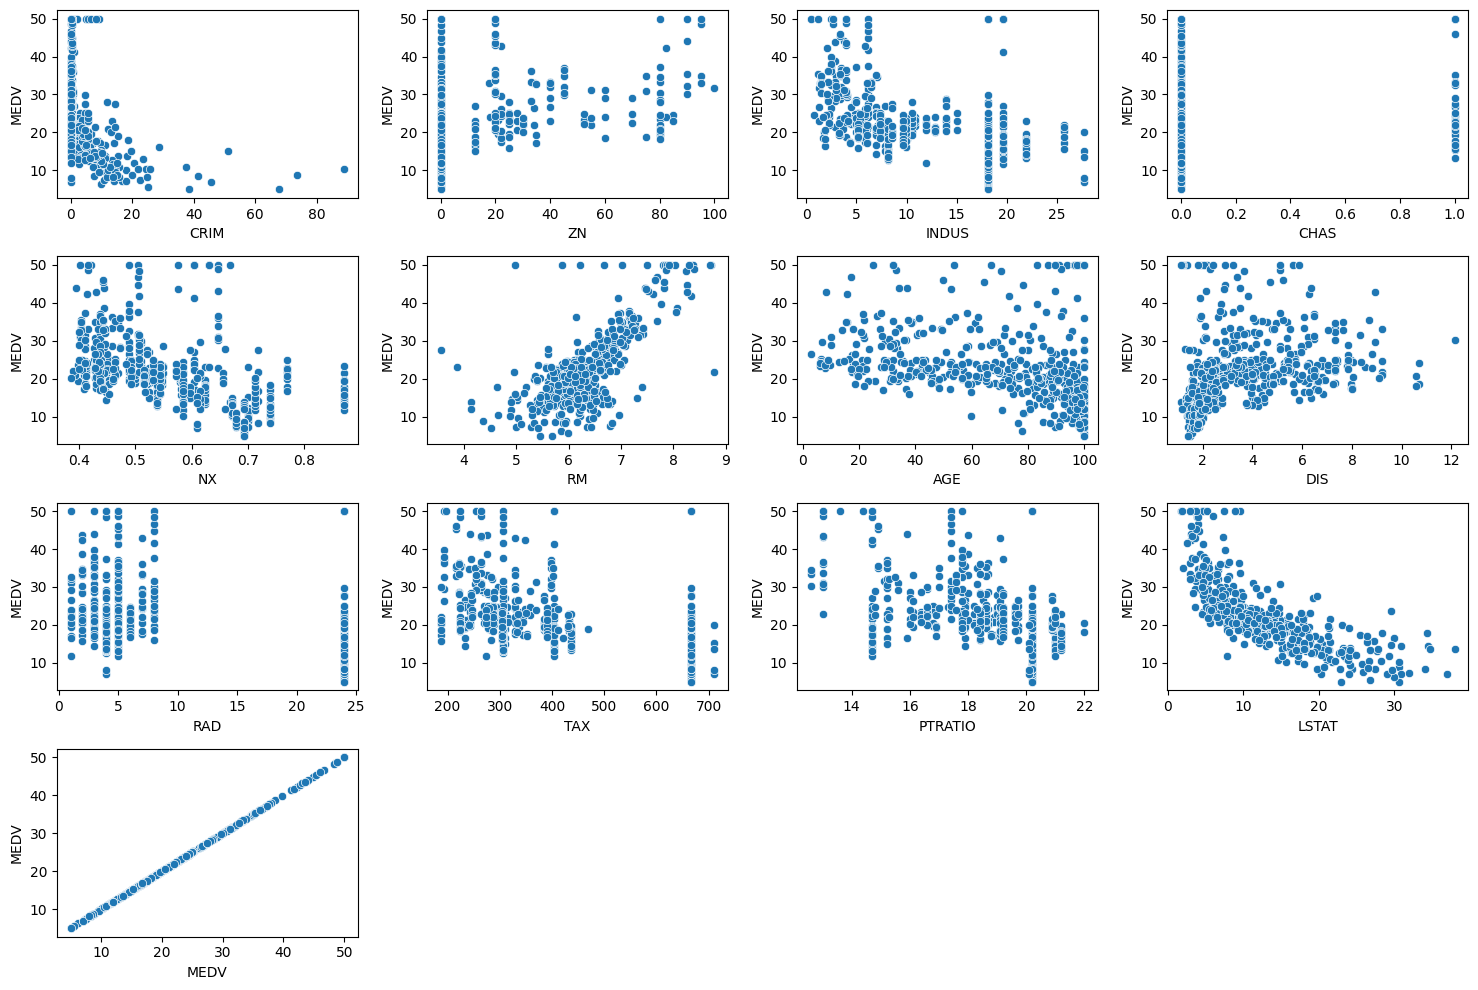

<IPython.core.display.Javascript object>

In [22]:
plt.figure(figsize=(15, 10))

features = df.columns

for i, feature in enumerate(features):
    plt.subplot(4, 4, i+1)
    sns.scatterplot(data=df, x=feature, y="MEDV")
plt.tight_layout()
plt.show()

<a id="header-11-visualizing-correlations--heatmap"><h3>Visualizing Correlations: Heatmap</h3></a>

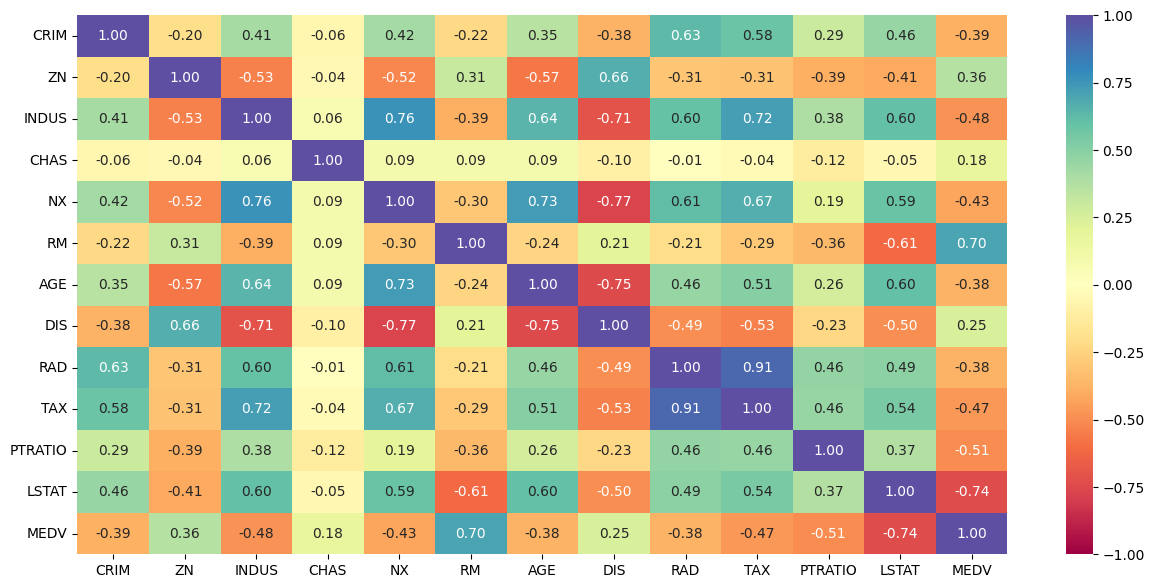

<IPython.core.display.Javascript object>

In [23]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

<a id="header-13-visualizing-correlations--pairplot"><h3>Visualizing Correlations: Pairplot</h3></a>

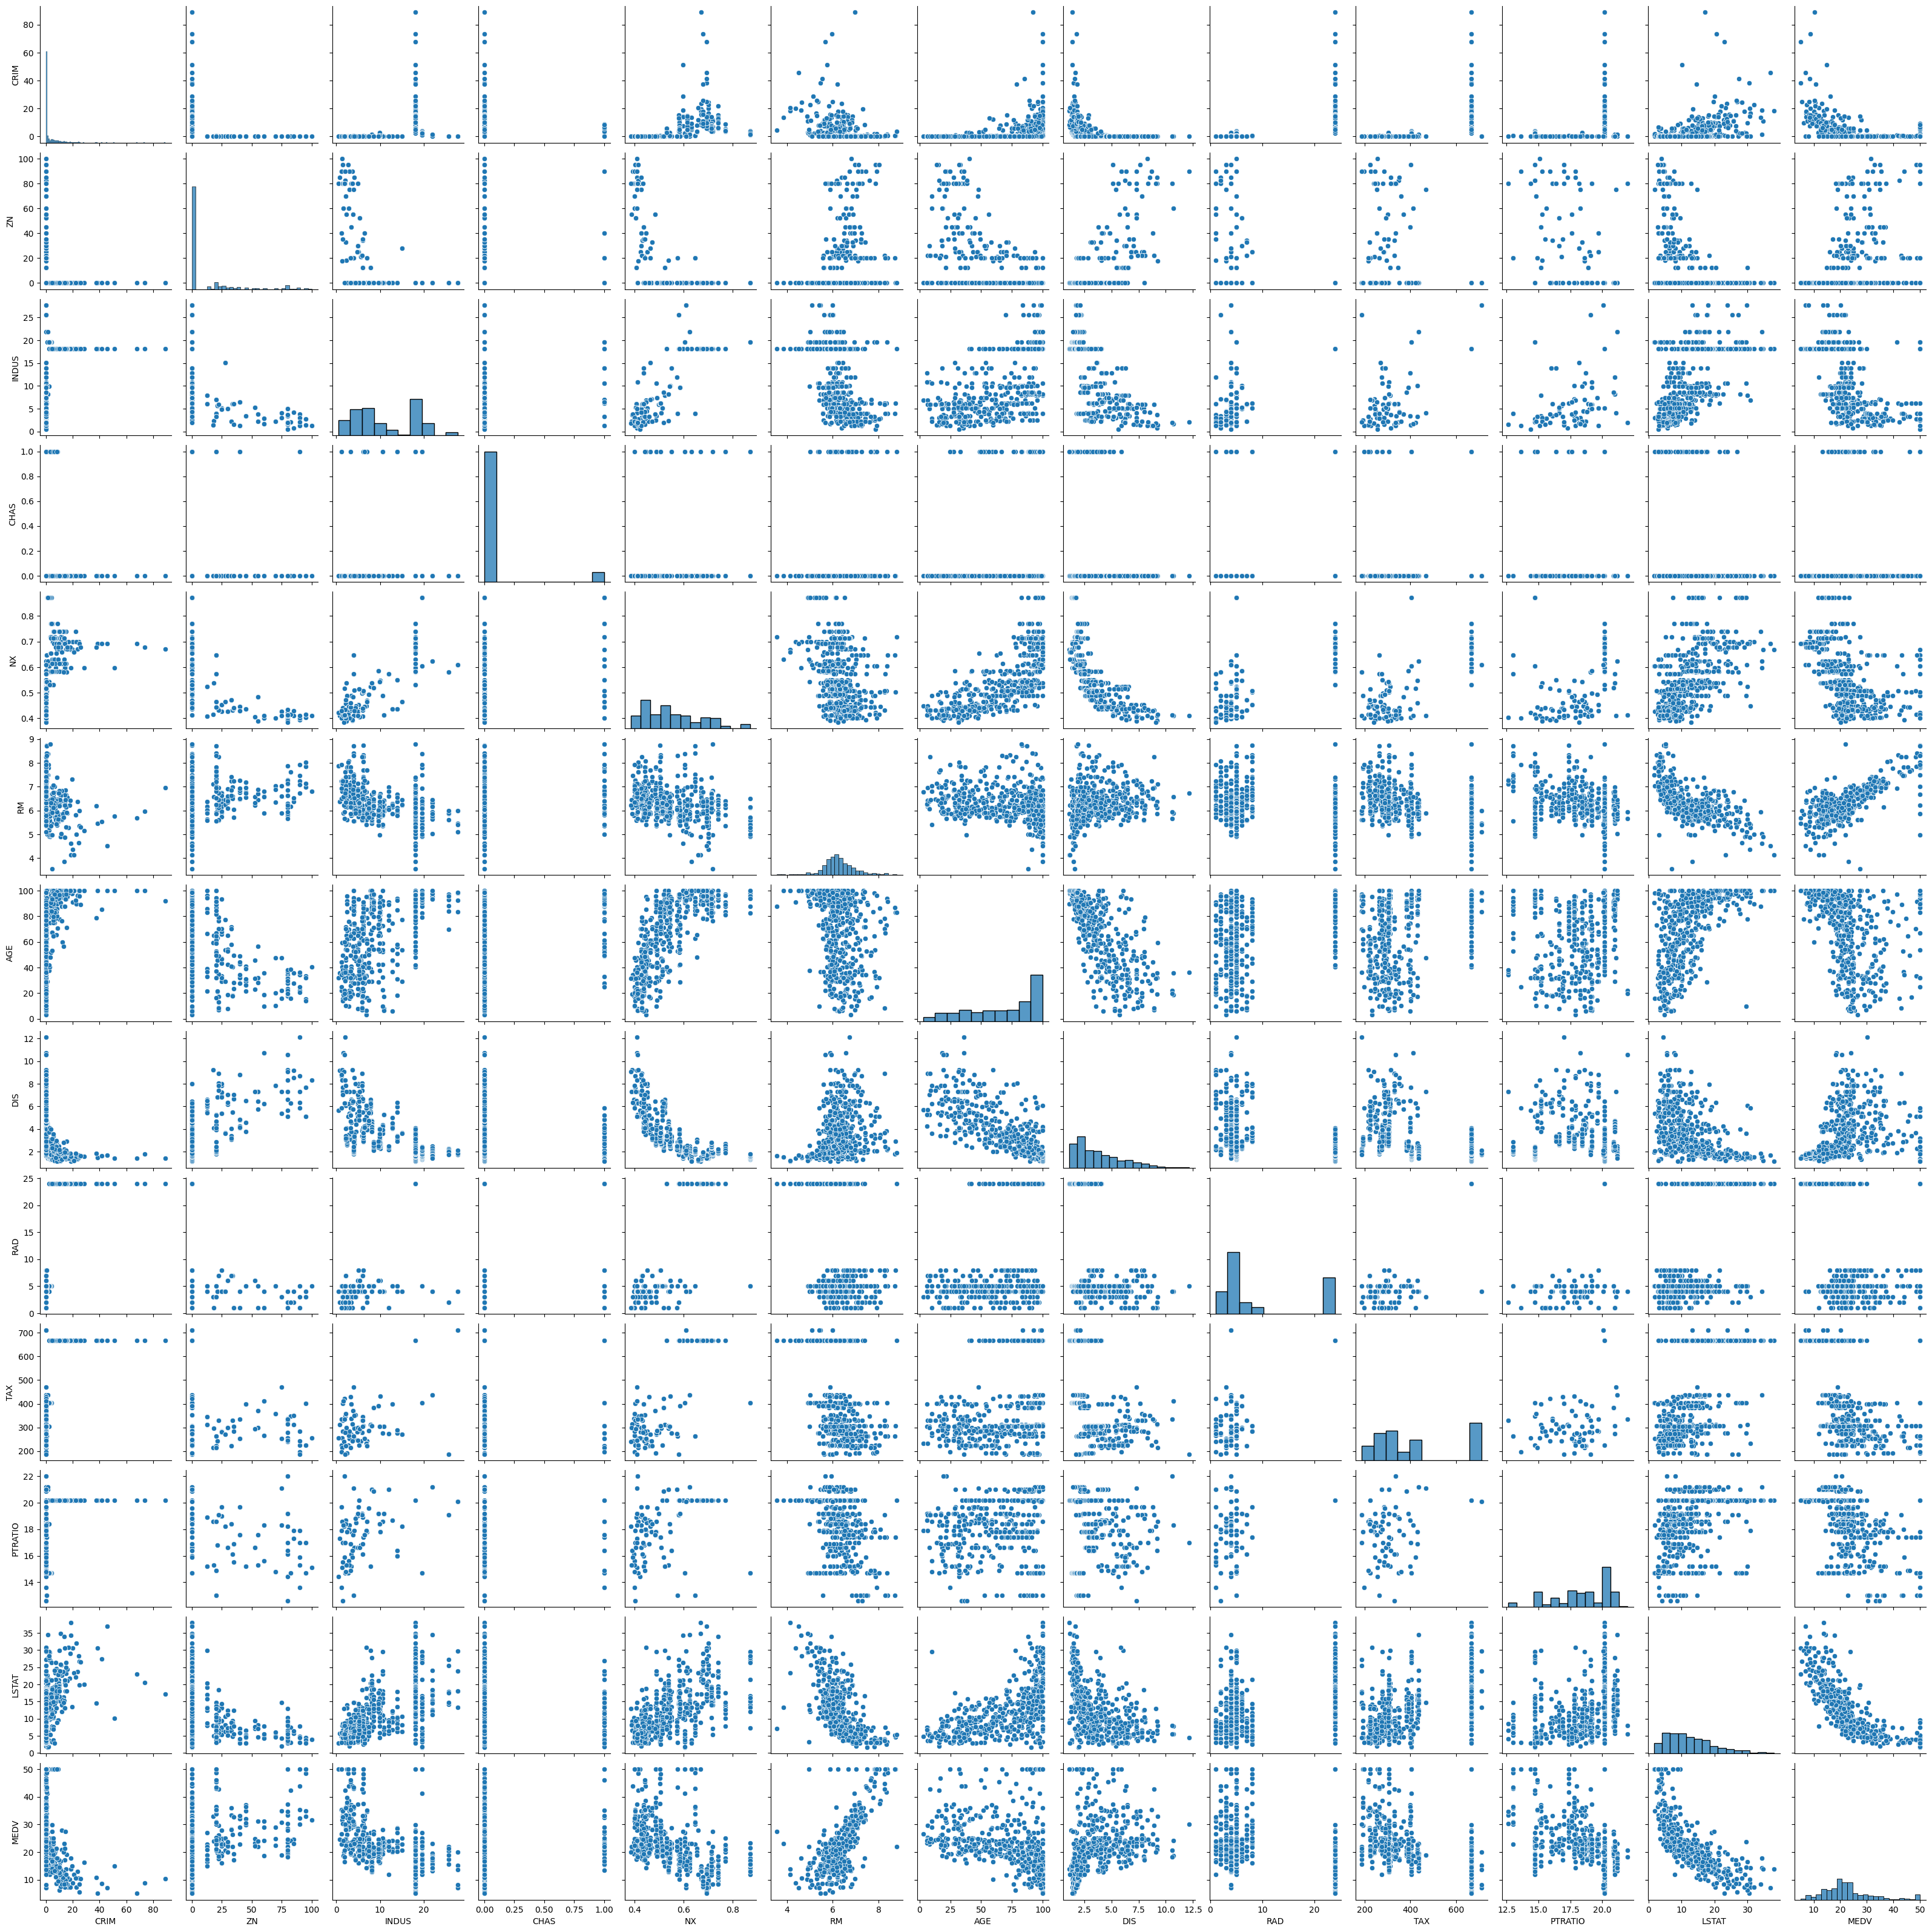

<IPython.core.display.Javascript object>

In [39]:
sns.pairplot(df);

* NX and TAX show a slightly strong positive linear relationship with INDUS, while DIS shows a slightly strong negative linear relationship with INDUS.
* NX shows a slightly strong positive linear relationship with AGE, while DIS shows a slightly strong negative linear relationship with AGE.
* RM shows a slightly strong positive linear relationship with MEDV, while LSTAT shows a slightly strong negative linear relationship with MEDV.

<a id="header-16-linear-regression-model-development"><h2>Linear Regression Model Development</h2></a><a id="header-16-split-the-dataset"><h3>Split the dataset</h3></a>

In [24]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

<IPython.core.display.Javascript object>

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

<IPython.core.display.Javascript object>

<a id="header-19-create-model-&-fit-the-data"><h3>Create Model & Fit the Data</h3></a>

In [26]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

<IPython.core.display.Javascript object>

<a id="header-21-preview-r2-on-training-data"><h4>Preview R2 on Training Data</h4></a>

In [27]:
print(
    "The score (R-squared) on the training set is ",
    regression_model.score(X_train, y_train),
)

The score (R-squared) on the training set is  0.707373205885618


<IPython.core.display.Javascript object>

<a id="header-23-a-manual-r2-calcuator"><h4>A Manual R2 Calcuator</h4></a>

In [29]:
# 
# r2
# SST - sum squared total
# SSE - sum squared error
# 
def r_squared(model, X, y):
    y_mean = y.mean()
    SST = ((y - y_mean) ** 2).sum()
    SSE = ((y - model.predict(X)) ** 2).sum()
    r_square = 1 - SSE / SST
    return SSE, SST, r_square


SSE, SST, r_square = r_squared(regression_model, X_train, y_train)
print("SSE: ", SSE)
print("SST: ", SST)
print("R-squared: ", r_square)

SSE:  8410.365734587127
SST:  28740.928389830508
R-squared:  0.707373205885618


<IPython.core.display.Javascript object>

<a id="header-25-preview-r2-on-testing-data"><h4>Preview R2 on Testing Data</h4></a>

In [31]:
print(
    "The score (R-squared) on the test set is ", regression_model.score(X_test, y_test)
)

The score (R-squared) on the test set is  0.7721684899134131


<IPython.core.display.Javascript object>

<a id="header-27-rmse-on-training-data"><h4>RMSE on Training Data</h4></a>

In [33]:
print(
    "The Root Mean Square Error (RMSE) of the model for the training set is ",
    np.sqrt(mean_squared_error(y_train, regression_model.predict(X_train))),
)

The Root Mean Square Error (RMSE) of the model for the training set is  4.874227661429435


<IPython.core.display.Javascript object>

<a id="header-29-rmse-on-testing-data"><h4>RMSE on Testing Data</h4></a>

In [34]:
print(
    "The Root Mean Square Error (RMSE) of the model for the test set is ",
    np.sqrt(mean_squared_error(y_test, regression_model.predict(X_test))),
)

The Root Mean Square Error (RMSE) of the model for the test set is  4.5696586527458285


<IPython.core.display.Javascript object>

<a id="header-31-model-&-feature-coefficients"><h4>Model & Feature Coefficients</h4></a>

In [35]:
coef_df = pd.DataFrame(
    np.append(regression_model.coef_, regression_model.intercept_),
    index=X_train.columns.tolist() + ["Intercept"],
    columns=["Coefficients"],
)

coef_df

,Coefficients
CRIM,-0.113845
ZN,0.061170
INDUS,0.054103
CHAS,2.517512
NX,-22.248502
RM,2.698413
AGE,0.004836
DIS,-1.534295
RAD,0.298833
TAX,-0.011414


<IPython.core.display.Javascript object>

<a id="header-33-visualize-a-math-equation-on-model-fit"><h4>Visualize a Math Equation on Model Fit</h4></a>

In [37]:
Equation = "Price = " + str(regression_model.intercept_)
print(Equation, end=" ")

for i in range(len(X_train.columns)):
    if i != len(X_train.columns) - 1:
        print(
            "+ (",
            regression_model.coef_[i],
            ")*(",
            X_train.columns[i],
            ")",
            end="  ",
        )
    else:
        print("+ (", regression_model.coef_[i], ")*(", X_train.columns[i], ")")

Price = 49.885234663817315 + ( -0.11384484836914074 )*( CRIM )  + ( 0.06117026804060947 )*( ZN )  + ( 0.054103464958745656 )*( INDUS )  + ( 2.5175119591227397 )*( CHAS )  + ( -22.248502345084436 )*( NX )  + ( 2.6984128200099096 )*( RM )  + ( 0.004836047284752856 )*( AGE )  + ( -1.5342953819992615 )*( DIS )  + ( 0.29883325485901713 )*( RAD )  + ( -0.011413580552025196 )*( TAX )  + ( -0.9889146257039377 )*( PTRATIO )  + ( -0.5861328508499136 )*( LSTAT )


<IPython.core.display.Javascript object>

<a id="header-35-setup-for-predictions"><h2>Setup For Predictions</h2></a>The model is already setup to predict new results on new data.  
Using `regression_model.predict()` and passing in an instance of a data row will return a prediction.  
The input of the new data must be in the same shape & order as the original datasource.